1. IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


2. LOAD & CLEAN DATA

In [2]:
df = pd.read_csv("C:\\Users\\HP-PC\\Downloads\\log.csv")
print(df.shape)
df.head()
df = df.drop_duplicates()

df = df.fillna(df.mean(numeric_only=True))

df = df[df['DPOR'] >= 0]
df = df[df['RHOB'] > 0]
df = df[df['CNLS'] >= 0]
df = df[df['DPOR'] < df['DPOR'].quantile(0.99)]

print(df.shape)



(8739, 14)
(8595, 14)


3. FEATURE SELECTION AND SCALING

In [3]:
X = df[['Depth','GR', 'DPOR', 'RHOB', 'RILD', 'SP']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


4. ELBOW METHOD 

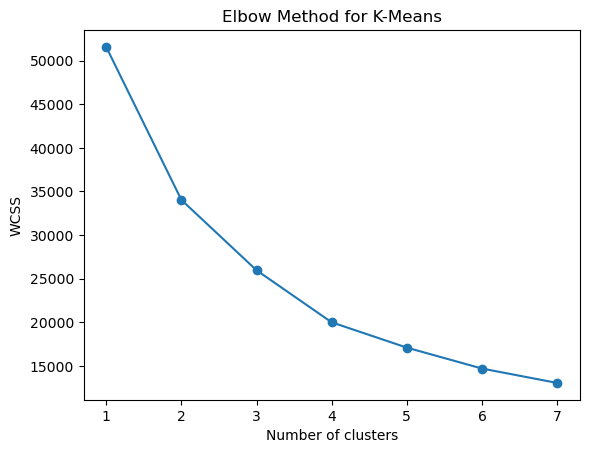

In [4]:
wcss = []
#within cluster sum of squares
for k in range(1, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 8), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method for K-Means")
plt.show()



5. KMEANS MODEL

In [5]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

df['Cluster_KMeans'] = clusters



6. SILHOUETTE SCORE

In [6]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)


Silhouette Score: 0.3770387286202884


7. PCA VISUALIZATION

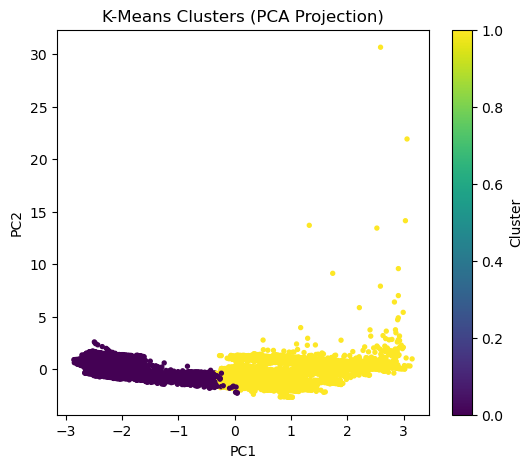

In [7]:
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=clusters, cmap='viridis', s=8)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()


In [11]:
df.groupby('Cluster_KMeans')[['Depth','GR','RILD','DPOR','RHOB','SP']].mean()


,Depth,GR,RILD,DPOR,RHOB,SP
Cluster_KMeans,,,,,,
0,3889.409227,69.705434,31.236735,14.955944,2.454254,-78.754603
1,1680.639148,82.478623,27.109902,54.365702,1.780346,-102.940168


In [14]:
folder_path = os.path.abspath("saved_models")
os.makedirs(folder_path, exist_ok=True)
kmeans_path = os.path.join(folder_path, "kmeans.pkl")
scaler_path = os.path.join(folder_path, "kmeans_scaler.pkl")

joblib.dump(kmeans, kmeans_path)
joblib.dump(scaler, scaler_path)

print("KMeans model saved successfully.")


KMeans model saved successfully.


In [15]:
df['Model'] = 'KMeans'
df['sand_score'] = None
df["Facies"] = None
df.to_csv('kmeans_output.csv', index=False)
